In [612]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [613]:
data = pd.read_csv('../consolidated_dataset/consolidated.csv')

In [614]:
for i in range(data.shape[0]):
    if data.loc[i, 'price_change'] == -1:
        data.loc[i, 'price_change'] = 0

In [615]:
target = 'price_change'

train = data.sample(frac=0.9, random_state=1)
test = data.drop(train.index).sample(frac=1.0, random_state=1)

y_train = train[target]
x_train = train.drop(columns=target)

y_test = test[target]
x_test = test.drop(columns=target)

In [616]:
# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()
# x_train = sc.fit_transform(x_train)
# x_test = sc.transform(x_test)

In [617]:
import tensorflow as tf

modelo = tf.keras.Sequential()
modelo.add(tf.keras.Input(shape=x_train.shape[1]))
modelo.add(tf.keras.layers.Dense(20))
modelo.add(tf.keras.layers.Dense(20))
modelo.add(tf.keras.layers.Dense(2))

modelo.summary()

Model: "sequential_52"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_155 (Dense)           (None, 20)                27920     
                                                                 
 dense_156 (Dense)           (None, 20)                420       
                                                                 
 dense_157 (Dense)           (None, 2)                 42        
                                                                 
Total params: 28,382
Trainable params: 28,382
Non-trainable params: 0
_________________________________________________________________


In [618]:
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               loss='mse',
               metrics=['accuracy'])

In [619]:
epoch = 500
historial = modelo.fit(x_train, y_train,
                       validation_data=(x_test, y_test),
                       batch_size=64,
                       epochs=epoch)

Epoch 1/500
3/3 [==============================] - 1s 93ms/step - loss: 19.7449 - accuracy: 0.5225 - val_loss: 8.2398 - val_accuracy: 0.6000
Epoch 2/500
3/3 [==============================] - 0s 17ms/step - loss: 10.7238 - accuracy: 0.5112 - val_loss: 2.4168 - val_accuracy: 0.6500
Epoch 3/500
3/3 [==============================] - 0s 16ms/step - loss: 2.1629 - accuracy: 0.6180 - val_loss: 6.1862 - val_accuracy: 0.5500
Epoch 4/500
3/3 [==============================] - 0s 16ms/step - loss: 3.7910 - accuracy: 0.5562 - val_loss: 0.6213 - val_accuracy: 0.6000
Epoch 5/500
3/3 [==============================] - 0s 16ms/step - loss: 1.7262 - accuracy: 0.6236 - val_loss: 3.1479 - val_accuracy: 0.6000
Epoch 6/500
3/3 [==============================] - 0s 17ms/step - loss: 2.0119 - accuracy: 0.5899 - val_loss: 0.6070 - val_accuracy: 0.6000
Epoch 7/500
3/3 [==============================] - 0s 17ms/step - loss: 0.5294 - accuracy: 0.4888 - val_loss: 1.6168 - val_accuracy: 0.5000
Epoch 8/500
3/3 [=

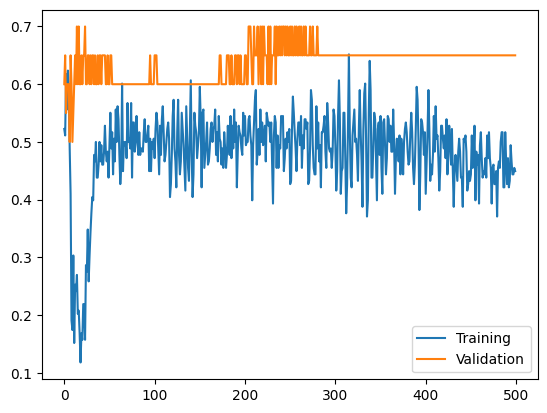

In [620]:
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']

plt.plot(range(epoch), acc, label='Training')
plt.plot(range(epoch), val_acc, label='Validation')
plt.legend(loc='lower right')

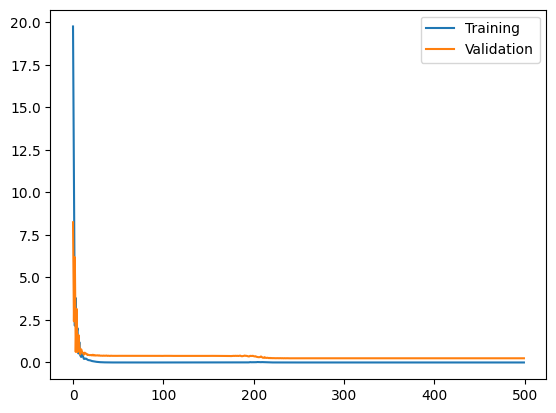

In [621]:
loss = historial.history['loss']
val_loss = historial.history['val_loss']

plt.plot(range(epoch), loss, label='Training')
plt.plot(range(epoch), val_loss, label='Validation')
plt.legend(loc='upper right')

In [622]:
score = modelo.evaluate(x_test, y_test, verbose=0)

print(f"Loss: {score[0]:.4f}")
print(f"Accuracy: {score[1]:.4f}")

Loss: 0.2467
Accuracy: 0.6500


1/1 [==============================] - 0s 55ms/step


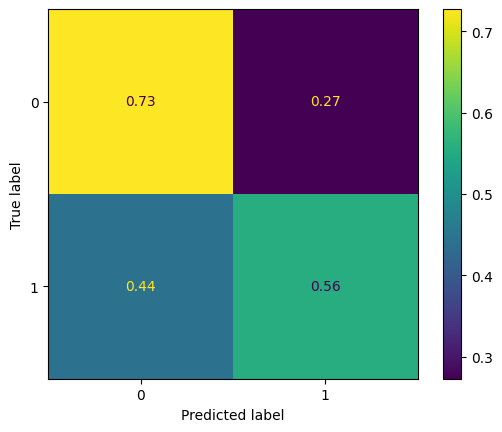

In [623]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = modelo.predict(x_test)

cf = confusion_matrix(y_test, list(map(np.argmax, y_pred)), normalize='true')
ConfusionMatrixDisplay(cf).plot()